In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/final_metadata.csv")
required_columns = ["video_id", "title", "datetime", "transcript"]
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")
print("All required columns present")

BEST_MODEL = "multi-qa-MiniLM-L6-cos-v1"
BEST_METRIC = "cosine"

title_embeddings = np.load("../data/title_embeddings.npy")
transcript_embeddings = np.load("../data/transcript_embeddings.npy")

All required columns present


In [2]:
print("Metadata shape:", df.shape)
print("Title embeddings shape:", title_embeddings.shape)
print("Transcript embeddings shape:", transcript_embeddings.shape)

Metadata shape: (217, 4)
Title embeddings shape: (217, 384)
Transcript embeddings shape: (217, 384)


In [3]:
combined_embeddings = 0.3 * title_embeddings + 0.7 * transcript_embeddings
print("Combined shape:", combined_embeddings.shape)
embedding_df = pd.DataFrame(combined_embeddings)
embedding_dim = combined_embeddings.shape[1]
embedding_df.columns = [f"emb_{i}" for i in range(embedding_dim)]
final_df = pd.concat([df, embedding_df], axis=1)
print("Final dataset shape:", final_df.shape)
final_df.head()

Combined shape: (217, 384)
Final dataset shape: (217, 388)


,video_id,title,datetime,transcript,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
0,KGVpKPNUdzA,Khabib vs Lex: Training with Khabib | FULL EXC...,2026-02-25,[Lex] All right. We're training with the Khabi...,-0.011134,0.029237,0.023949,-0.052703,-0.037568,0.071175,...,0.090085,0.050960,-0.084281,0.021811,-0.037674,-0.013464,-0.025635,0.015907,-0.008922,0.011621
1,YFjfBk8HI5o,OpenClaw: The Viral AI Agent that Broke the In...,2026-02-12,"- I watched my agent happily click the ""I'm no...",-0.006191,-0.107095,-0.031676,-0.046824,0.022702,0.033652,...,0.015205,0.018775,0.020557,-0.064464,-0.017788,0.058181,0.001029,0.017298,0.048867,0.009677
2,EV7WhVT270Q,"State of AI in 2026: LLMs, Coding, Scaling Law...",2026-01-31,- The following is a conversation all about th...,-0.047564,-0.113781,-0.008190,-0.058883,0.032966,0.123650,...,0.076698,0.053705,-0.061308,-0.066854,-0.065806,0.069400,0.043714,-0.037885,-0.013278,0.078460
3,Z-FRe5AKmCU,Paul Rosolie: Uncontacted Tribes in the Amazon...,2026-01-13,- ... were standing there. Everyone is waiting...,0.005778,-0.041444,0.027730,0.029519,0.096083,-0.015146,...,0.085844,0.018410,0.005107,0.060228,-0.018694,0.055271,0.010633,-0.007049,-0.069700,0.001311
4,14OPT6CcsH4,"Infinity, Paradoxes, Gödel Incompleteness &amp...",2025-12-31,- The following is a conversation with Joel Da...,-0.058031,-0.040032,0.004658,0.048868,0.000742,-0.019905,...,0.063012,-0.004456,-0.059840,0.023605,-0.202434,0.035830,0.110208,0.006893,-0.049519,-0.012066


In [4]:
final_df.to_parquet("../data/video_index.parquet", index=False)
print("Saved as Parquet")

Saved as Parquet


In [5]:
print("Dataset rows:", len(final_df))
print("Original videos:", len(df))
assert len(final_df) == len(df)
print("Row count matches")

embedding_cols = [col for col in final_df.columns if col.startswith("emb_")]
print("Number of embedding columns:", len(embedding_cols))
embedding_lengths = final_df[embedding_cols].apply(lambda row: len(row), axis=1)
print("Unique embedding lengths:", embedding_lengths.unique())

sample_vector = final_df.iloc[0][embedding_cols].values
print("Sample embedding shape:", sample_vector.shape)
print("First 5 values:", sample_vector[:5])

Dataset rows: 217
Original videos: 217
Row count matches
Number of embedding columns: 384
Unique embedding lengths: [384]
Sample embedding shape: (384,)
First 5 values: [-0.011134431 0.029237054 0.023949092 -0.052702993 -0.037568066]


In [6]:
import numpy as np
from sklearn.decomposition import PCA

X = final_df[embedding_cols].values
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("PCA shape:", X_pca.shape)

PCA shape: (217, 2)


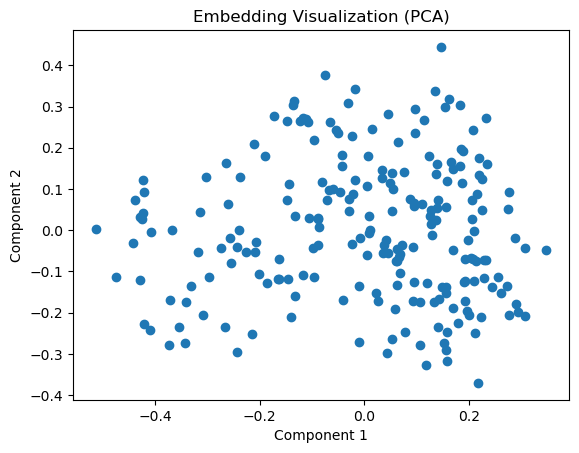

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])

plt.title("Embedding Visualization (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()